# Just place to do some checks as writing up...

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
folder = 'outputs/runs/'

import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [4]:
baseline_files = {
    'Grid':       f'{folder}grid_city_Falsewalking_Falsedelay_1compliance.pkl',
    'Moderate':   f'{folder}moderate_city_Falsewalking_Falsedelay_1compliance.pkl',
    'Bottleneck': f'{folder}bottleneck_city_Falsewalking_Falsedelay_1compliance.pkl',
}

In [5]:
from utils.comparison_metrics import extract_results

results = extract_results(baseline_files['Grid'])

In [11]:
seed_results = []

for seed in results['greedy']['solutions']:
    start_points = [agent.start_point for agent in seed.values()]
    seed_results.append(start_points)

In [13]:
import pandas as pd
from collections import Counter

def count_agents_per_start(seed_results: list) -> pd.DataFrame:
    rows = []
    for seed_idx, seed in enumerate(seed_results):
        counts = Counter(seed)
        counts['Seed'] = seed_idx + 1
        rows.append(counts)
    
    df = pd.DataFrame(rows).fillna(0).set_index('Seed')
    df = df.astype(int)
    
    # sort columns
    df = df.reindex(sorted(df.columns), axis=1)
    
    return df

df = count_agents_per_start(seed_results)
print(df.to_string())

      S1  S2  S3  S4
Seed                
1     33  17  22  28
2     32  16  18  34
3     24  25  23  28
4     22  31  27  20
5     29  28  23  20
6     22  28  25  25
7     30  30  19  21
8     24  21  26  29
9     25  21  29  25
10    30  27  28  15


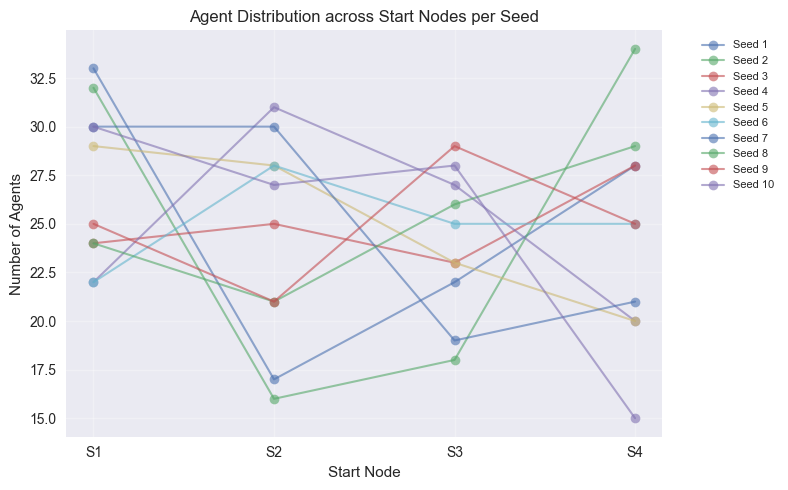

In [15]:
import matplotlib.pyplot as plt

def plot_agent_start_distribution(seed_results: list) -> None:
    start_nodes = sorted(set(s for seed in seed_results for s in seed))
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    for seed_idx, seed in enumerate(seed_results):
        counts = Counter(seed)
        values = [counts.get(s, 0) for s in start_nodes]
        ax.plot(start_nodes, values, marker='o', linewidth=1.5, 
                alpha=0.6, label=f'Seed {seed_idx + 1}')
    
    ax.set_xlabel("Start Node")
    ax.set_ylabel("Number of Agents")
    ax.set_title("Agent Distribution across Start Nodes per Seed")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_agent_start_distribution(seed_results)